In [3]:
# To check that dataset ('AEP_hourly.csv') has been uploaded.
# Source: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

import os
os.listdir('/content')

['.config', 'AEP_hourly.csv', 'sample_data']

In [15]:
# ============================================================
# ****** SETUP: IMPORTS + CONFIG ******
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error

forecast_horizon = 168

In [24]:
# ============================================================
# ****** STEP 1: DATASET OVERVIEW ******
# ============================================================
# Load dataset, inspect structure, check missing values,
# and prepare datetime index.

df = pd.read_csv("AEP_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df.set_index("Datetime", inplace=True)

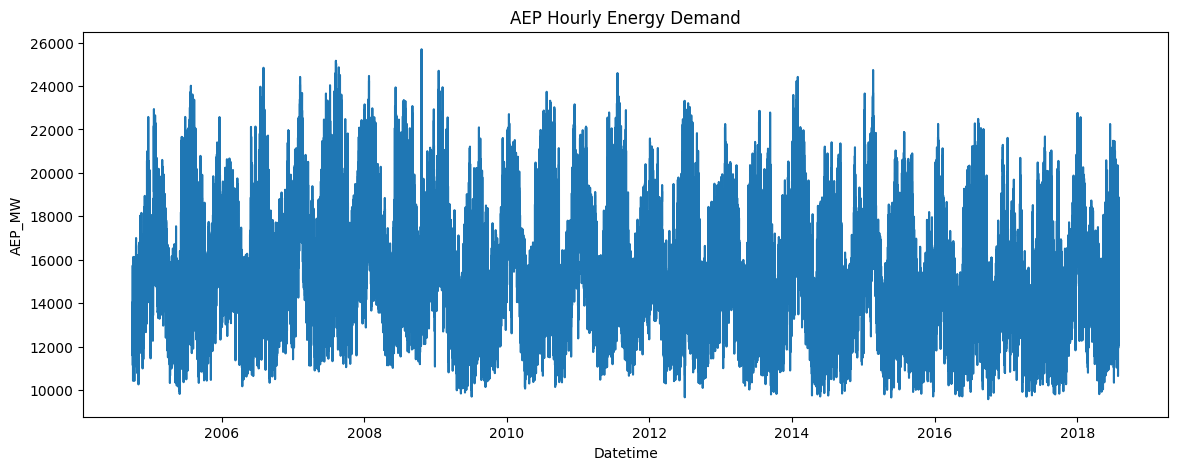

In [25]:
# ============================================================
# ****** STEP 2: TIME-SERIES VISUALIZATION ******
# ============================================================
# Plot electricity demand over time.

plt.figure(figsize=(14,5))
plt.plot(df["AEP_MW"])
plt.title("AEP Hourly Energy Demand")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")
plt.show()

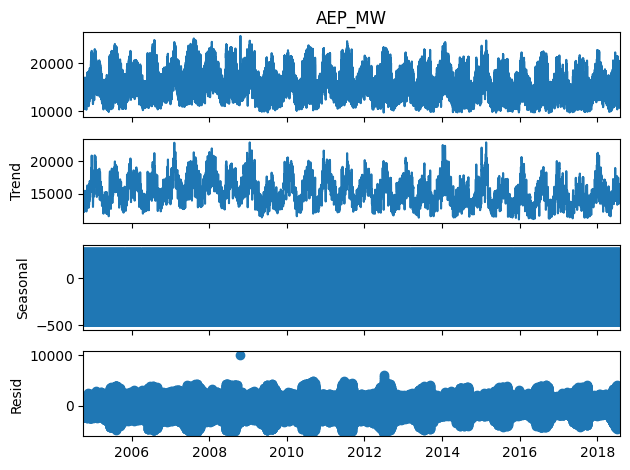

In [26]:
# ============================================================
# ****** STEP 3: TREND AND SEASONALITY DECOMPOSITION ******
# ============================================================
# Decompose the series into trend, seasonal, and residual parts.

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["AEP_MW"],
    model="additive",
    period=24
)

decomposition.plot()
plt.show()

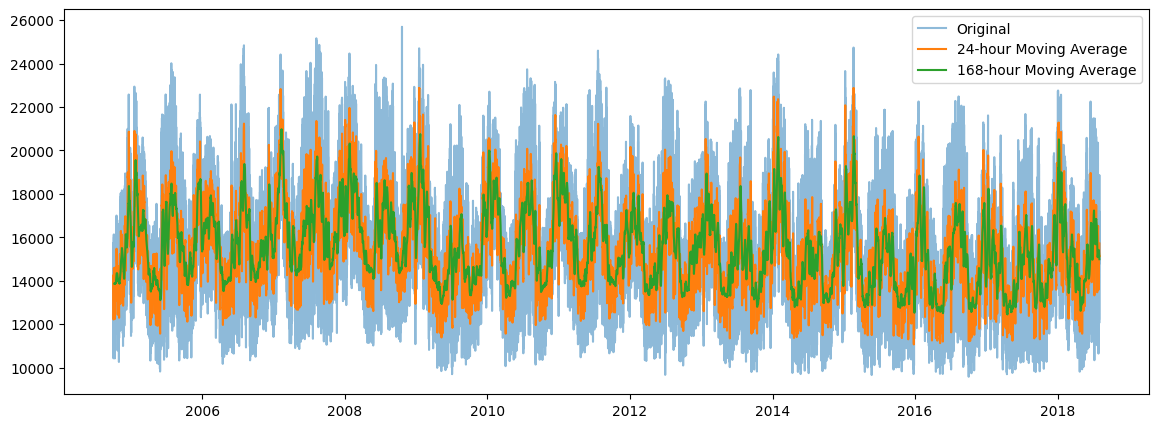

In [27]:
# ============================================================
# ****** STEP 4: MOVING AVERAGES ******
# ============================================================
# Calculate rolling averages to smooth short-term fluctuations.

df["MA_24"] = df["AEP_MW"].rolling(window=24).mean()
df["MA_168"] = df["AEP_MW"].rolling(window=168).mean()

plt.figure(figsize=(14,5))
plt.plot(df["AEP_MW"], label="Original", alpha=0.5)
plt.plot(df["MA_24"], label="24-hour Moving Average")
plt.plot(df["MA_168"], label="168-hour Moving Average")
plt.legend()
plt.show()

In [28]:
# ============================================================
# ****** STEP 5: TRAIN-TEST SPLIT ******
# ============================================================
# Reserve the last 168 hours for testing and forecasting.

forecast_horizon = 168

train = df["AEP_MW"][:-forecast_horizon]
test = df["AEP_MW"][-forecast_horizon:]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 121105
Testing samples: 168


In [30]:
# ============================================================
# ****** STEP 6: ARIMA MODEL FITTING ******
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 AEP_MW   No. Observations:               121105
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -864872.812
Date:                Thu, 11 Jun 2026   AIC                        1729755.623
Time:                        14:34:15   BIC                        1729804.145
Sample:                             0   HQIC                       1729770.223
                             - 121105                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6722      0.002    962.668      0.000       1.669       1.676
ar.L2         -0.7630      0.002   -460.282      0.000      -0.766      -0.760
ma.L1         -0.7108      0.001   -588.493      0.0

In [35]:
# ============================================================
# ****** STEP 7: FORECASTING ******
# ============================================================

forecast = model_fit.forecast(steps=168)
forecast.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
121105,14103.986179
121106,13515.770121
121107,13312.653986
121108,13421.779969
121109,13759.230801


In [33]:
# ============================================================
# ****** STEP 8: PERFORMANCE EVALUATION ******
# ============================================================
# Evaluate forecasting accuracy using MAE and RMSE.

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = root_mean_squared_error(test, forecast)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 1854.23
RMSE: 2385.34


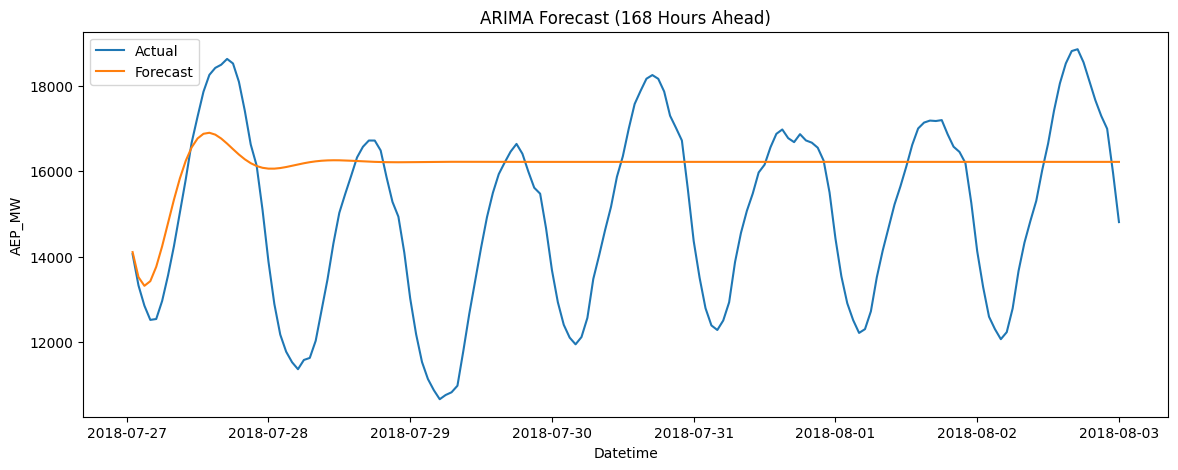

In [34]:
# ============================================================
# ****** STEP 9: FORECAST VISUALIZATION ******
# ============================================================
# Compare actual and predicted values.

plt.figure(figsize=(14,5))

plt.plot(test.index, test,
         label="Actual")

plt.plot(test.index, forecast,
         label="Forecast")

plt.title("ARIMA Forecast (168 Hours Ahead)")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")

plt.legend()
plt.show()